In [ ]:
"""
03_dimensionality_reduction.ipynb
==================================
Applies feature selection and linear transformation to preprocessed profiles.
Follows Step 2 of the analysis pipeline.
Current feature selection pipeline:
    1. remove low-variance features
    2. replicate correlation filtering (remove features with low replicate correlation across healthy/disease wells)
    3. correlation filtering (remove "redundant" features that correlate highly with other features)
    4. 2-stage Cohen's d filtering:
        4.1. filter for features where Cohen's d between healthy and disease groups > threshold (affected by disease axis)
        4.2. filter for featuers where Cohen's d between treatment and disease groups > threshold (carry some treatment singla)

TODO: 
    - experiment with other feature selection steps (SVM-RFE, mRMR) and dimensionality reduction techniques (Sphering after PCA, MDA) to see if results improve downstream
    - validate best feature selection choices with downstream results (similarity metrics) in script 5 -- current config seems pretty good
    - confirm which feature selection steps should be used and at which level (per-plate or global), consider tradeoffs -- global (current) is ideal

Inputs:
    - outputs/01_preprocessed_features.csv (preprocessed output from 02_preprocess.ipynb)

Outputs:
    - outputs/02_pca_profiles.csv (PC1-10, for similarity metrics that use PCA)
    - outputs/02_pca_models.pkl (PCA model object with info like explained variance)
    - outputs/02_plate_selected_features.json (selected features per plate, for metrics that don't use PCA)
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import json
import pickle
from skimage.filters import threshold_otsu
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal
from pathlib import Path

In [2205]:
OUTPUT_DIR = Path("../outputs")
df = pd.read_csv(OUTPUT_DIR / "01_preprocessed_features.csv")

meta_cols = ["plate", "session", "batch", "row", "column", "compound", "dose_uM", "cell_type", "condition", "num_wells"]
original_feature_cols = [c for c in df.columns if c not in meta_cols]

In [2210]:
# Helper functions for 2a. Feature Selection (variance thresholding and correlation filtering)

def variance_threshold(df, feature_cols, threshold=0.1, method='mad'):
    """
    Removes near-zero variance features as a first pass before more expensive filtering methods (Step 2a).
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        threshold: threshold below which features are removed (default 0.1)
        method: 'mad' (recommended) or 'std'
    
    Returns:
        retained: filtered list of feature column names
    """
    all_scores = pd.DataFrame(index=feature_cols)
    all_scores['std'] = df[feature_cols].std()
    all_scores['mad'] = df[feature_cols].apply(lambda x: (x - x.median()).abs().median())

    if method == 'std':
        scores = all_scores['std']
    elif method == 'mad':
        scores = all_scores['mad']
    else:
        raise ValueError("method must be 'std' or 'mad'")
    
    removed = scores[scores < threshold].index.tolist()
    retained = scores[scores >= threshold].index.tolist()
    
    print(f"Variance thresholding ({method} < {threshold}):")
    print(f"  Input features:   {len(feature_cols)}")
    print(f"  Retained:         {len(retained)}")
    
    if removed:
        print(f"\n  Removed {len(removed)} features with {method} < {threshold}:")
        removed_df = all_scores.loc[removed].sort_values(by=method)
        
        for row in removed_df.itertuples():
            print(f"    {row.Index:<120} (std={row.std:.4f}, mad={row.mad:.4f})")
    
    return retained

def correlation_filter(df, feature_cols, threshold=0.90):
    """
    Removes redundant features via iterative correlation filtering (Step 2a).
    At each step, removes the feature with the highest mean absolute correlation to all others when any pair exceeds the threshold.
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        threshold: correlation threshold (default 0.90)
    
    Returns:
        filtered list of feature column names
    """
    print(f"Starting correlation filtering (threshold={threshold})...")
    
    # Compute initial absolute correlation matrix
    corr_matrix = df[feature_cols].corr().abs()
    np.fill_diagonal(corr_matrix.values, 0)     # Fill diagonal with 0 so a feature doesn't correlate with itself during the mean calculation
    
    current_features = list(feature_cols)
    removed_count = 0

    while True:
        # Find pairs that exceed the threshold (check upper triangle)
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        bad_pairs = np.where(upper > threshold)
        
        # If no pairs exceed threshold, we are done
        if len(bad_pairs[0]) == 0:
            break
            
        # Identify all features involved in at least one 'bad'(highly correlated) pair
        guilty_indices = np.unique(np.concatenate([bad_pairs[0], bad_pairs[1]]))
        guilty_features = corr_matrix.index[guilty_indices]
        
        # Find which 'guilty' feature has the highest mean correlation to all others (most "globally redundant" feature)
        mean_corrs = corr_matrix.loc[guilty_features].mean(axis=1)
        feature_to_drop = mean_corrs.idxmax()
        
        # 5. Remove the feature from the matrix and the list
        corr_matrix = corr_matrix.drop(index=feature_to_drop, columns=feature_to_drop)
        current_features.remove(feature_to_drop)
        removed_count += 1
        
        # Update progress every 50 features removed
        if removed_count % 50 == 0:
            print(f"  Removed {removed_count} features... {len(current_features)} remaining", end="\r")

    print(f"\nFiltering complete.")
    print(f"  Input features   : {len(feature_cols)}")
    print(f"  Removed          : {removed_count}")
    print(f"  Retained         : {len(current_features)}")
    
    return current_features

def replicate_correlation_filter(df, feature_cols, threshold=0.5, min_features=50, plot=True):
    """
    Filters features by biological replicate consistency (Step 2a).
    
    RC Score = 1 - (std_replicate / std_global). 
    - 1.0: Perfect consistency (no noise).
    - 0.0: Noise equals total population variance (useless).
    
    Retains features meeting the absolute threshold in both 'healthy' and 'disease'.
    """

    global_std = df[feature_cols].std(axis=0).values
    global_std = np.where(global_std < 1e-8, 1e-8, global_std)

    condition_scores = []
    replicate_conditions = ['healthy', 'disease']
    for condition in replicate_conditions:
        cond_df = df[df['condition'] == condition][feature_cols]
        within_std = cond_df.std(axis=0).values
        condition_scores.append(1.0 - (within_std / global_std))

    # Conservative: feature must be consistent in both conditions
    final_scores = np.minimum(*condition_scores)

    rc_df = pd.DataFrame({
        'feature': feature_cols,
        'rc_score': final_scores
    }).sort_values('rc_score', ascending=False).reset_index(drop=True)

    # cutoff = np.percentile(final_scores, drop_percentile)
    # score_map = dict(zip(feature_cols, final_scores))
    # retained = rc_df.loc[rc_df['rc_score'] >= cutoff, 'feature'].tolist()
    retained = rc_df.loc[rc_df['rc_score'] >= threshold, 'feature'].tolist()

    if len(retained) < min_features:
        retained = rc_df['feature'].iloc[:min_features].tolist()

    print(f"Replicate correlation filter: {len(feature_cols)} → {len(retained)} features retained")
    print(f"  Threshold: {threshold} (absolute)")

    if plot:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].hist(final_scores, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
        axes[0].axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.3f}')
        axes[0].set_xlabel('RC Score')
        axes[0].set_ylabel('Feature count')
        axes[0].set_title(f'RC Score Distribution — {len(retained)}/{len(feature_cols)} retained')
        axes[0].legend()

        axes[1].scatter(condition_scores[0], condition_scores[1], alpha=0.3, s=8, color='steelblue')
        axes[1].axvline(threshold, color='red', linestyle='--', alpha=0.5)
        axes[1].axhline(threshold, color='red', linestyle='--', alpha=0.5)
        axes[1].set_xlabel(f'RC Score ({replicate_conditions[0]})', fontsize=12)
        axes[1].set_ylabel(f'RC Score ({replicate_conditions[1]})')
        axes[1].set_title('Per-condition RC Scores', fontsize=14)
        axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)

        plt.tight_layout()
        plt.show()

    return retained, rc_df

In [ ]:
# Helper functions for 2a. Feature Selection (Cohen's d based)

def _threshold_gmm(d_values):
    """
    Fit a 2-component GMM to |d| and return the crossing point.
    More flexible than Otsu, does not require clean bimodal distrbution
    Falls back to component mean midpoint if no crossing is found.
    """
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(d_values.reshape(-1, 1))

    means = gmm.means_.flatten()
    lo, hi = means.min(), means.max()

    # Scan for the point where posterior probability flips
    x_scan = np.linspace(lo, hi, 10_000).reshape(-1, 1)
    posteriors = gmm.predict_proba(x_scan)
    crossings = np.where(np.diff(np.argmax(posteriors, axis=1)))[0]

    if len(crossings) > 0:
        threshold = float(x_scan[crossings[0], 0])
    else:
        threshold = float((lo + hi) / 2)
        print("  GMM: no crossing found, using component midpoint as fallback.")

    print(f"  GMM component means: {lo:.3f}, {hi:.3f} → threshold: {threshold:.3f}")
    return threshold

def _threshold_permutation(healthy, disease, feature_cols, n_permutations=1000, percentile=95):
    """
    Build a null |d| distribution by permuting healthy/disease labels.
    Uses max |d| per permutation to control family-wise error rate.

    Returns:
        threshold: float
        null_max_d: array of per-permutation max |d| values (for plotting)
    """
    rng = np.random.default_rng(2026)

    combined = np.concatenate([healthy[feature_cols].values,
                                disease[feature_cols].values], axis=0)
    n_h, n_d = len(healthy), len(disease)
    n_total = n_h + n_d

    null_max_d = np.empty(n_permutations)

    for i in range(n_permutations):
        idx = rng.permutation(n_total)
        h_perm = combined[idx[:n_h]]
        d_perm = combined[idx[n_h:]]

        mean_diff = d_perm.mean(axis=0) - h_perm.mean(axis=0)
        var_h = h_perm.var(axis=0, ddof=1)
        var_d = d_perm.var(axis=0, ddof=1)
        pooled = np.sqrt(((n_h - 1) * var_h + (n_d - 1) * var_d) / (n_h + n_d - 2))
        pooled = np.where(pooled < 1e-10, np.nan, pooled)

        abs_d = np.abs(mean_diff / pooled)
        null_max_d[i] = np.nanmax(abs_d)

        if (i + 1) % 200 == 0:
            print(f"  Permutation {i + 1}/{n_permutations}...", end="\r")

    print()
    threshold = float(np.percentile(null_max_d, percentile))
    print(f"  Permutation null ({percentile}th pct of max |d|): {threshold:.3f}")
    return threshold, null_max_d

def cohen_d_filter(df, feature_cols, method='gmm', comparison_group='healthy', permutation_percentile=0, min_features=30, max_features=None, plot=True):
    """
    Select features that discriminate either healthy or treatment from disease using Cohen's d effect size.

    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        comparison_group: group to compare 'disease' group to (either 'healthy' or 'treatment')
        method: 
            - "gmm" (yielded lowest threshold)
            - "otsu" (expects bimodal dist, yielded middle threshold)
            - "permutation" (most robust, computationally expensive, control leniency)
        permutation_percentile: permutation shuffles A/B labels N times, computes null |d| distribution. This is percentile at which to threshold
        min/max_features: minimum or maximum features to retain
            
    Returns:
        filtered list of feature column names
    """
    def _compute_d(h: pd.DataFrame, d: pd.DataFrame) -> pd.Series:
        n_h, n_d = len(h), len(d)
        var_h = h[feature_cols].var(ddof=1)
        var_d = d[feature_cols].var(ddof=1)
        pooled = np.sqrt(((n_h - 1) * var_h + (n_d - 1) * var_d) / (n_h + n_d - 2))
        pooled = pooled.replace(0, np.nan)
        return ((d[feature_cols].mean() - h[feature_cols].mean()) / pooled).abs()
    
    print(f"\nCohen's d filtering: disease vs. {comparison_group}")

    # 1. Compute Cohen's d
    d_records: dict[str, pd.Series] = {}
    reference = df[df["condition"] == comparison_group]
    disease = df[df["condition"] == "disease"]
    d_records["global_d"] = _compute_d(reference, disease)
    score_col = "global_d"

    d_df = pd.DataFrame(d_records)
    scores = d_df[score_col].dropna().values

    # 2. Thresholding logic
    null_dist = None
    if method == "otsu":
        threshold = float(threshold_otsu(scores))
    elif method == "gmm":
        threshold = _threshold_gmm(scores)
    elif method == "permutation":
        n_permutations=1000
        threshold, null_dist = _threshold_permutation(
            reference, disease, feature_cols,
            n_permutations=n_permutations, percentile=permutation_percentile,
        )
    else:
        raise ValueError(f"Unknown method '{method}'.")

    retained = d_df.index[d_df[score_col] >= threshold].tolist()
    method_used = method

    # If too few features retained, try permutation then top-N
    if len(retained) < min_features:
        if method != "permutation":
            print(f"  Warning: {method} retained only {len(retained)} features, trying permutation...")
            threshold, null_dist = _threshold_permutation(
                reference, disease, feature_cols,
                n_permutations=n_permutations, percentile=percentile,
            )
            retained = d_df.index[d_df["global_d"] >= threshold].tolist()
            method_used = "permutation"
        if len(retained) < min_features:
            print(f"  Warning: permutation retained only {len(retained)} features, using top-{min_features}.")
            retained = d_df["global_d"].nlargest(min_features).index.tolist()
            threshold = float(d_df.loc[retained[-1], "global_d"])
            method_used = f"top_{min_features}"
            
    # Apply max_features constraint
    if max_features is not None and len(retained) > max_features:
        print(f"  Note: Capping {len(retained)} features to top {max_features} by Cohen's d.")
        retained = d_df.loc[retained, "global_d"].nlargest(max_features).index.tolist()
        threshold = float(d_df.loc[retained[-1], "global_d"])

    print(f"  Method    : {method_used}")
    print(f"  Threshold : {threshold:.3f}")
    print(f"  Input     : {len(feature_cols)}")
    print(f"  Retained  : {len(retained)}")

    # Visualization
    if plot:
        fig, ax = plt.subplots(figsize=(12, 3))
        # |d| distribution + threshold
        ax.hist(scores, bins=50, color="steelblue", edgecolor="white", alpha=0.8,
                label=f"n={len(scores)} features")
        ax.axvline(threshold, color="red", linewidth=2,
                label=f"{method_used} threshold = {threshold:.3f}")
        # Optional: overlay null distribution if permutation
        if null_dist is not None:
            ax_twin = ax.twinx()
            ax_twin.hist(null_dist, bins=30, color="orange", alpha=0.35,
                        label="Null max |d|")
            ax_twin.set_ylabel("Permutation count", color="orange", fontsize=10)
            ax_twin.legend(loc="lower right", fontsize=9)
        ax.set_title(f"Cohen's d (threshold method={method_used})", fontsize=14)
        ax.set_xlabel(f"\n|Cohen's d|", fontsize=14)
        ax.set_ylabel("Feature count", fontsize=14)
        ax.legend(loc='upper right', fontsize=12, title_fontsize=12)
        ax.tick_params(axis='both', labelsize=12)
        plt.tight_layout()
        plt.show()

    return retained, d_df

In [2208]:
# Ideas for helper functions for 2b. Linear Transformation

def fit_pca(df, feature_cols, fit_mode="controls", n_components=0.99):
    """
    Function to fit PCA and project all data into the new space. Can fit on controls only (robust) or all wells (legacy).
    
    Args:
        df: profiles dataframe
        feature_cols: list of feature column names
        fit_mode:
            "controls": Fits only on healthy/disease (prevents axis rotation by drugs).
            "all": Fits on every well in the dataframe (replicates MATLAB logic).
        n_components: 
            If float (e.g. 0.90): Retains PCs explaining that % of variance.
            If int (e.g. 5): Retains a fixed number of components.
    
    Returns:
        df_out: DataFrame with PC scores and original metadata.
        pca: The fitted PCA object.
    """
    # 1. Determine data to fit PCA on
    if fit_mode == "controls":
        df_fit = df[df["condition"].isin(["healthy", "disease"])]
        print(f"\nFitting PCA on {len(df_fit)} healthy/disease wells...")
    elif fit_mode == "all":
        df_fit = df
        print(f"\nFitting PCA on all {len(df_fit)} wells...")
    else:
        raise ValueError("fit_mode must be either 'controls' or 'all'")

    X_fit = df_fit[feature_cols].values
    X_all = df[feature_cols].values

    # 2. Fit PCA
    max_components = min(len(X_fit), len(feature_cols))
    if isinstance(n_components, int):
        n_components = min(n_components, max_components)

    pca = PCA(n_components=n_components, random_state=2026)
    pca.fit(X_fit)
    
    # Ensure minimum of 2 components for plotting, even if variance threshold is too strict.
    if pca.n_components_ < 2:
        print("Variance threshold resulted in < 2 components. Forcing 2 PCs for plotting...")
        pca = PCA(n_components=2, random_state=2026)
        pca.fit(X_fit)

    # 3. Project all data into the new space
    X_pca = pca.transform(X_all)
    
    # 4. Create output DataFrame
    pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    df_pca_values = pd.DataFrame(X_pca, columns=pc_cols, index=df.index)
    
    # Join with metadata
    meta_cols = [c for c in df.columns if c not in feature_cols]
    df_out = pd.concat([df[meta_cols], df_pca_values], axis=1)
    
    print(f"PCA Complete:")
    print(f"  Components retained : {pca.n_components_}")
    print(f"  Variance explained  : {pca.explained_variance_ratio_.sum():.2%}")
        
    return df_out, pca

def plot_pca(df_pca, pca_model):
    color_map = {'disease': 'red', 'healthy': 'black', 'treatment': 'blue'}
    pc1_var, pc2_var = pca_model.explained_variance_ratio_[:2] * 100
    
    fig = go.Figure()
    for cond in df_pca['condition'].unique():
        data = df_pca[df_pca['condition'] == cond]
        if len(data) < 3: continue
        
        color = color_map.get(cond.lower(), 'gray')
        mu, cov = data[['PC1', 'PC2']].mean().values, data[['PC1', 'PC2']].cov().values
        
        # 1. Contours (Gaussian Islands)
        std_x, std_y = np.sqrt(np.diag(cov))
        x_range = np.linspace(mu[0]-3*std_x, mu[0]+3*std_x, 50)
        y_range = np.linspace(mu[1]-3*std_y, mu[1]+3*std_y, 50)
        X, Y = np.meshgrid(x_range, y_range)
        Z = multivariate_normal(mu, cov).pdf(np.dstack((X, Y)))
        
        fig.add_trace(go.Contour(
            x=x_range, y=y_range, z=Z, 
            colorscale=[[0, 'rgba(0,0,0,0)'], [1, color]], 
            showscale=False, contours_coloring='lines', line_width=1, opacity=0.4,
            hoverinfo='skip'
        ))

        # 2. Data Points (Interactive Hover)
        fig.add_trace(go.Scatter(
            x=data['PC1'], y=data['PC2'],
            mode='markers',
            marker=dict(color=color, size=10, line=dict(width=0.5, color='white')),
            name=cond.capitalize(),
            customdata=np.stack((data['compound'], data['dose_uM']), axis=-1),
            hovertemplate="<b>%{customdata[0]}</b><br>Dose: %{customdata[1]}<br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<extra></extra>"
        ))
        # 3. Centroid (Star)
        fig.add_trace(go.Scatter(
            x=[mu[0]], y=[mu[1]],
            mode='markers',
            marker=dict(color=color, size=18, symbol='star', line=dict(width=0.5, color='white')),
            showlegend=False, hoverinfo='skip'
        ))

    # Styling
    plate_id = df_pca['plate'].iloc[0]
    fig.update_layout(
        title=dict(text=f"<b>PCA Space</b>", x=0.5, xanchor='center', font=dict(size=18)),
        xaxis=dict(title=f"PC1 ({pc1_var:.2f}% variance)", showgrid=True, gridcolor='lightgray', title_font=dict(size=16), tickfont=dict(size=16)),
        yaxis=dict(title=f"PC2 ({pc2_var:.2f}% variance)", showgrid=True, gridcolor='lightgray', title_font=dict(size=16), tickfont=dict(size=16)),
        template="plotly_white",
        width=1200,
        height=600,
        legend_title="Conditions"
    )
    
    fig.show()

def apply_sphering(df, pca_cols):
    """
    Applies ZCA whitening (sphering) fitted on healthy wells only (Step 2b).
    Transforms the PCA space so features have equal variance and are uncorrelated,
    with the healthy state defining the geometry.
    Confirm healthy wells form a roughly spherical cloud in the first 2 PCs after whitening.
    
    Args:
        df: profiles dataframe with PCA scores
        pca_cols: list of PC column names
    
    Returns:
        df with sphered PCA scores
    """
    pass

In [ ]:
print("="*60)
print("1. FEATURE SELECTION 1: VARIANCE THRESHOLDING")
print("="*60)
print()

print("Remove near-zero variance features as a first filtering pass.\n")
feature_cols_var_1 = variance_threshold(df, original_feature_cols, method='mad', threshold=0.1)     # Can also use method='std'

1. FEATURE SELECTION 1: VARIANCE THRESHOLDING

Remove near-zero variance features as a first filtering pass.

Variance thresholding (mad < 0.1):
  Input features:   2126
  Retained:         2077

  Removed 49 features with mad < 0.1:
    Nuclei - CellPainting Nucleus Region Sapphire Profile 2/2 SER-Hole - Median per Well                                     (std=0.2261, mad=0.0000)
    Nuclei - CellPainting Ring Region PhenoVue 641 Mito Stain Profile 1/2  - Median per Well                                 (std=0.0000, mad=0.0000)
    Nuclei - CellPainting Ring Region PhenoVue Fluor 555 Profile 1/2  - Median per Well                                      (std=0.0000, mad=0.0000)
    Nuclei - CellPainting Nucleus Region PhenoVue Fluor 555 Threshold Compactness 60% SER-Spot - Median per Well             (std=0.9562, mad=0.0000)
    Nuclei - CellPainting Nucleus Region Sapphire Profile 2/2 SER-Valley - Median per Well                                   (std=0.7646, mad=0.0000)
    Nuclei - Cel

2. FEATURE SELECTION 2: REPLICATION FILTERING

Remove features with low replicate correlation as a second filtering pass.

Replicate correlation filter: 2077 → 1404 features retained
  Threshold: 0.3 (absolute)


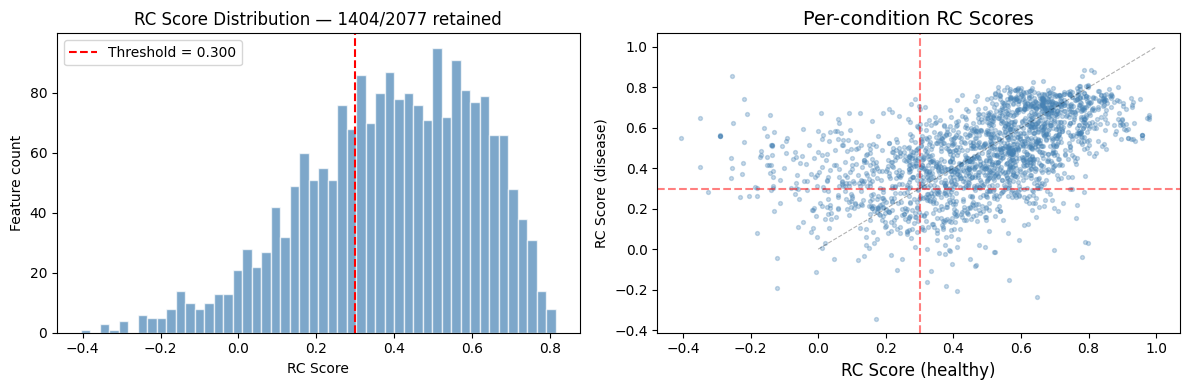

In [2211]:
print("="*60)
print("2. FEATURE SELECTION 2: REPLICATION FILTERING")
print("="*60)
print()

print("Remove features with low replicate correlation as a second filtering pass.\n")

# Either 0.25 or 0.30 seems to be a good threshold for Nuclei feeatures
feature_cols_replicate_2, rc_df = replicate_correlation_filter(df, feature_cols_var_1, threshold=0.30)

In [2275]:
print("="*60)
print("3. FEATURE SELECTION 3: CORRELATION FILTERING")
print("="*60)
print()

print("Remove redundant features via iterative correlation filtering as a third filtering pass.\n")

# 0.90 or 0.95 seem to be a pretty good threshold for now. 
# Don't want to be too harsh to avoid eliminating a redundant feature that might show treatment effects more, but don't want to keep too many especially working with only Nuclei features now
feature_cols_corr_3 = correlation_filter(df, feature_cols_replicate_2, threshold=0.90)

3. FEATURE SELECTION 3: CORRELATION FILTERING

Remove redundant features via iterative correlation filtering as a third filtering pass.

Starting correlation filtering (threshold=0.9)...
  Removed 1000 features... 404 remaining
Filtering complete.
  Input features   : 1404
  Removed          : 1022
  Retained         : 382


4. FEATURE SELECTION 4: COHEN'S D FILTERING

Remove features based on Cohen's d between target groups as a fourth filtering pass.

Cohen's d filtering: disease vs. healthy
  GMM component means: 2.014, 3.764 → threshold: 3.019
  Note: Capping 160 features to top 100 by Cohen's d.
  Method    : gmm
  Threshold : 3.650
  Input     : 382
  Retained  : 100


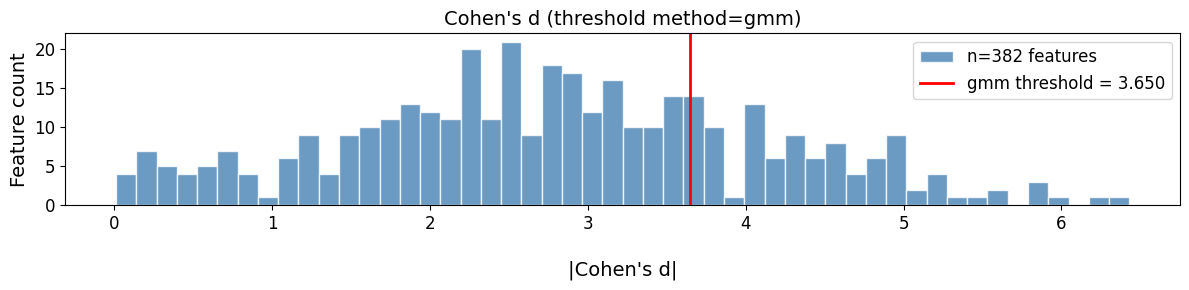


Cohen's d filtering: disease vs. treatment
  Permutation 1000/1000...
  Permutation null (0th pct of max |d|): 0.170
  Method    : permutation
  Threshold : 0.170
  Input     : 100
  Retained  : 57


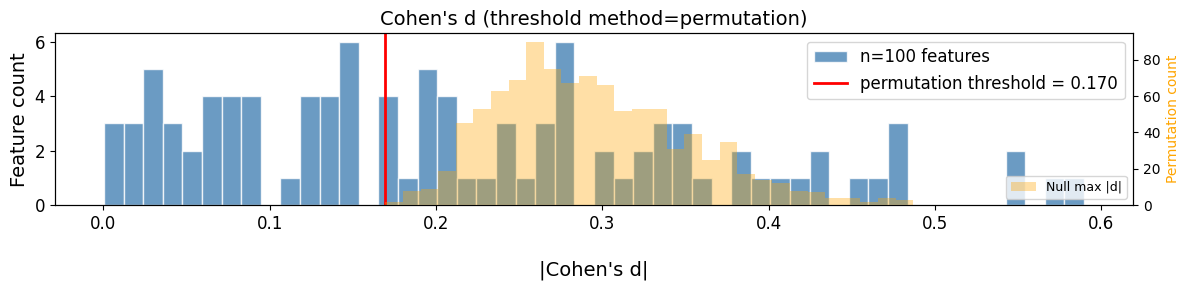

In [2276]:
print("="*60)
print("4. FEATURE SELECTION 4: COHEN'S D FILTERING")
print("="*60)
print()

"""
Cohen’s d prioritizes effect size (magnitude of difference relative to variability), not just statistical significance.
A feature can be statistically significant with a trivially small difference that adds noise to PCA.

Threshold selection (pick one):
- Otsu’s method: Treat the |d| distribution as a histogram; find the threshold maximizing between-class variance. Simple, automatic, works well when bimodal.
- Gaussian mixture model: Fit a 2-component GMM to |d|. Use the intersection as the threshold. More flexible if not cleanly bimodal.
- Permutation null: Shuffle A/B labels N times, compute null |d| distribution. Threshold at 95th/99th percentile. Most rigorous, most expensive.
"""

print("Remove features based on Cohen's d between target groups as a fourth filtering pass.")

# This first pass selects top 100 features differentiating "healthy" vs. "disease", since permutation gmm and otsu methods had too leniant of thresholds 
# (most of our features differentate healthy vs disease)
feature_cols_cohens_4, d_df = cohen_d_filter(df, feature_cols_corr_3, comparison_group='healthy', method='gmm', max_features=100, plot=True)

# This second pass selects features differentiating "treatment" vs "disease" to select for features with some treatment effect
# Permutation builds a null distribution of effect sizes from random labels, so 0% for example keeps only features stronger than any random effect.
feature_cols_cohens_5, d_df = cohen_d_filter(df, feature_cols_cohens_4, comparison_group='treatment', method='permutation', permutation_percentile=0, min_features=30, plot=True)

In [2281]:
MODE = "global"  # "per_plate" or "global", found that "global" worked better and is preferred anyway so downstream results can be compared

print("=" * 60)
print(f"5. PCA ({MODE.upper()})")
print("=" * 60)

all_pca_dfs = []
pca_models = {}
plate_features = {}
plates = sorted(df["plate"].unique())

pca_features = feature_cols_cohens_5

if MODE == "global":
    for plate in plates:
        plate_features[plate] = pca_features

    # PCA once on all data
    df_filtered = df[meta_cols + pca_features]
    df_pca_all, model = fit_pca(
        df_filtered, pca_features,
        fit_mode='controls', n_components=15
    )
    df_pca_all = df_pca_all.reset_index(drop=True)

    # Same model for all plates
    for plate in plates:
        pca_models[plate] = model
else:  # per_plate
    for i, plate in enumerate(plates):
        print(f"\n[{i+1}/{len(plates)}] {plate}")
        print("-" * 40)

        df_plate = df[df["plate"] == plate]

        # refit cohen's d features if running per-plate
        retained, d_df = cohen_d_filter(df_plate, feature_cols_corr_3, comparison_group='healthy', method='gmm', min_features=50, plot=False)
        # retained, d_df = cohen_d_filter(df, retained_healthy, comparison_group='treatment', method='permutation', percentile=20, min_features=50, plot=False)

        plate_features[plate] = retained
        df_plate_filtered = df_plate[meta_cols + retained]

        df_pca, model = fit_pca(
            df_plate_filtered, retained,
            fit_mode='all', n_components=15
        )
        pca_models[plate] = model
        all_pca_dfs.append(df_pca)

    df_pca_all = pd.concat(all_pca_dfs, axis=0).reset_index(drop=True)

# Save
pca_file = OUTPUT_DIR / "02_pca_profiles.csv"
features_file = OUTPUT_DIR / "02_plate_selected_features.json"
models_file = OUTPUT_DIR / "02_pca_models.pkl"

df_pca_all.to_csv(pca_file, index=False)

with open(features_file, "w") as f:
    json.dump(plate_features, f, indent=2)

with open(models_file, "wb") as f:
    pickle.dump(pca_models, f)

# Summary
pc_cols = [c for c in df_pca_all.columns if c.startswith("PC")]

print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print(f"Mode                 : {MODE}")
print(f"Plates processed     : {len(plates)}")
print(f"Total wells          : {len(df_pca_all)}")
print(f"PCs saved            : {len(pc_cols)}")
print(f"\nOutput files:")
print(f"  - {pca_file}")
print(f"  - {features_file}")
print(f"  - {models_file}")

5. PCA (GLOBAL)

Fitting PCA on 204 healthy/disease wells...
PCA Complete:
  Components retained : 15
  Variance explained  : 94.94%

Summary
Mode                 : global
Plates processed     : 13
Total wells          : 471
PCs saved            : 15

Output files:
  - ..\outputs\02_pca_profiles.csv
  - ..\outputs\02_plate_selected_features.json
  - ..\outputs\02_pca_models.pkl


In [2282]:
print("=" * 60)
print("6. VISUALIZE PC1 AND PC2")
print("=" * 60)

df_pca_all = pd.read_csv(OUTPUT_DIR / "02_pca_profiles.csv")

with open(OUTPUT_DIR / "02_plate_selected_features.json") as f:
    plate_features = json.load(f)

with open(OUTPUT_DIR / "02_pca_models.pkl", "rb") as f:
    pca_models = pickle.load(f)

# Plot all plates (healthy and disease groups should tightly cluster, otherwise batch effects)
df_plot = df_pca_all
model = list(pca_models.values())[0]  # all plates share the same model
plate_id = "all plates"

print(f"\nPlate      : {plate_id}")
print(f"Wells      : {len(df_plot)}")
print(f"Conditions : {df_plot['condition'].value_counts().to_dict()}")
print(f"Features   : {len(plate_features[list(plate_features.keys())[0]])} retained after Cohen's d")

plot_pca(df_plot, model)

# Plot particular plate
plate_id = df_pca_all["plate"].unique()[11]  # change index to inspect different plates
df_plot = df_pca_all[df_pca_all["plate"] == plate_id]
model = pca_models[plate_id]

print(f"\nPlate      : {plate_id}")
print(f"Wells      : {len(df_plot)}")
print(f"Conditions : {df_plot['condition'].value_counts().to_dict()}")
print(f"Features   : {len(plate_features[list(plate_features.keys())[0]])} retained after Cohen's d")

plot_pca(df_plot, model)

6. VISUALIZE PC1 AND PC2

Plate      : all plates
Wells      : 471
Conditions : {'treatment': 267, 'disease': 102, 'healthy': 102}
Features   : 57 retained after Cohen's d



Plate      : CE_CP_5CH_10X_Lot1_02062026
Wells      : 54
Conditions : {'treatment': 18, 'disease': 18, 'healthy': 18}
Features   : 57 retained after Cohen's d
